<a href="https://colab.research.google.com/github/Sidharth-1506/Data-Science-Lab-Work/blob/main/ML_Intermediate_level_project_SidharthGautam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project we are going to perform clustering analysis and try to group customers based on their similarities
Data: For this Project dataset has been taken from Kaggle credit: https://www.kaggle.com/code/sachinbhardwaj97/customer-segmentation-k-means-pca-4-segments/input?select=marketing_campaign.csv
Here are Most of the features present in the dataset and what they mean
* ID: Customer's unique identifier
* Year_Birth: Customer's birth year
* Education: Customer's education level
* Marital_Status: Customer's marital status
* Income: Customer's yearly household income
* Kidhome: Number of children in customer's household
* Teenhome: Number of teenagers in customer's household
* Dt_Customer: Date of customer's enrollment with the company
* Recency: Number of days since customer's last purchase
* MntWines: Amount spent on wine in the last 2 years
* MntFruits: Amount spent on fruits in the last 2 years
* MntMeatProducts: Amount spent on meat in the last 2 years
* MntFishProducts: Amount spent on fish in the last 2 years
* MntSweetProducts: Amount spent on sweets in the last 2 years
* MntGoldProds: Amount spent on gold in the last 2 years
* NumDealsPurchases: Number of purchases made with a discount
* NumWebPurchases: Number of purchases made through company's web site
* NumCatalogPurchases: Number of purchases made using a catalogue
* NumStorePurchases: Number of purchases made directly in stores
* NumWebVisitsMonth: Number of visits to company's web site in the last month
* AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
* AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
* AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
* AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
* AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
* Response: 1 if customer accepted the offer in the last campaign, 0 otherwise
* Complain: 1 if customer complained in the last 2 years, 0 otherwise

In [70]:
# Step 1: Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [39]:
# Step 2: Load the data
df = pd.read_excel("/content/Customer segmentation dataset.xlsx")

In [40]:
# View first rows
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [41]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [42]:
# Step 3: Data Exploration
# Check missing values
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


since only Income has missing values that are around only 1% of data. we can drop the rows containing those missing values

In [43]:
# Drop rows with missing Income
df = df.dropna(subset=["Income"])

# Verify removal
print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


In [44]:
# Summary statistics
print(df.describe())

                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   2216.000000  2216.000000    2216.000000  2216.000000  2216.000000   
mean    5588.353339  1968.820397   52247.251354     0.441787     0.505415   
min        0.000000  1893.000000    1730.000000     0.000000     0.000000   
25%     2814.750000  1959.000000   35303.000000     0.000000     0.000000   
50%     5458.500000  1970.000000   51381.500000     0.000000     0.000000   
75%     8421.750000  1977.000000   68522.000000     1.000000     1.000000   
max    11191.000000  1996.000000  666666.000000     2.000000     2.000000   
std     3249.376275    11.985554   25173.076661     0.536896     0.544181   

                         Dt_Customer      Recency     MntWines    MntFruits  \
count                           2216  2216.000000  2216.000000  2216.000000   
mean   2013-07-10 11:29:27.509025280    49.012635   305.091606    26.356047   
min              2012-07-30 00:00:00     0.000000     0.000000     0.

Next We will combine and convert some columns to make columns that will be useful for the analysis

In [45]:
# Step 4: Data Cleaning
# Customer age
df['Age'] = 2026 - df['Year_Birth']

# Total spending across all product categories
df['Total_Spent'] = (df['MntWines'] + df['MntFruits'] +
                     df['MntMeatProducts'] + df['MntFishProducts'] +
                     df['MntSweetProducts'] + df['MntGoldProds'])

# Total number of purchases
df['Total_Purchases'] = (df['NumDealsPurchases'] + df['NumWebPurchases'] +
                         df['NumCatalogPurchases'] + df['NumStorePurchases'])

# Total children at home
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Customer tenure in days
df['Tenure'] = (pd.to_datetime('2026-01-01') - df['Dt_Customer']).dt.days

In [46]:
# drop the columns not needed anymore
cols_to_drop = [ "Year_Birth", "Kidhome", "Teenhome","MntWines", "MntFruits",
    "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "Dt_Customer", "ID", "Z_CostContact", "Z_Revenue"]
df.drop(columns=cols_to_drop, inplace=True)

In [47]:
print(df.describe())

              Income      Recency  NumWebVisitsMonth  AcceptedCmp3  \
count    2216.000000  2216.000000        2216.000000   2216.000000   
mean    52247.251354    49.012635           5.319043      0.073556   
std     25173.076661    28.948352           2.425359      0.261106   
min      1730.000000     0.000000           0.000000      0.000000   
25%     35303.000000    24.000000           3.000000      0.000000   
50%     51381.500000    49.000000           6.000000      0.000000   
75%     68522.000000    74.000000           7.000000      0.000000   
max    666666.000000    99.000000          20.000000      1.000000   

       AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2     Complain  \
count   2216.000000   2216.000000   2216.000000   2216.000000  2216.000000   
mean       0.074007      0.073105      0.064079      0.013538     0.009477   
std        0.261842      0.260367      0.244950      0.115588     0.096907   
min        0.000000      0.000000      0.000000      0.00

After checking on income and age we can see that both have potential outliers that needs removal to make clustering smoother

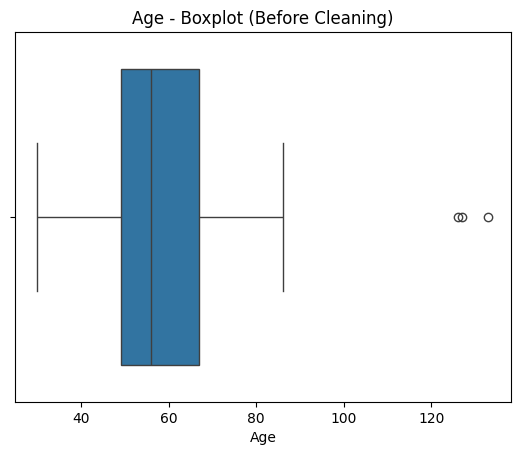

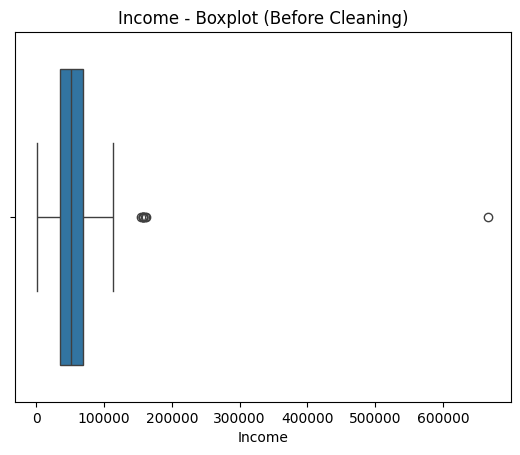

In [48]:
# Lets visualize to see How Age and Income Data Looks like

# Age boxplot
plt.figure()
sns.boxplot(x=df["Age"])
plt.title("Age - Boxplot (Before Cleaning)")
plt.show()

# Income boxplot
plt.figure()
sns.boxplot(x=df["Income"])
plt.title("Income - Boxplot (Before Cleaning)")
plt.show()

We will remove age outliers based on logical constraints, while income outliers will be treated using capping to preserve high-value customer segments without distorting clustering results.

In [49]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 90)]

Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df["Income"] = np.where(df["Income"] > upper, upper, df["Income"])

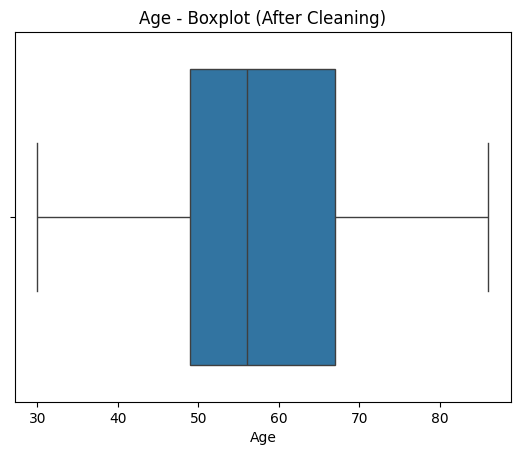

In [50]:
# Age boxplot
plt.figure()
sns.boxplot(x=df["Age"])
plt.title("Age - Boxplot (After Cleaning)")
plt.show()


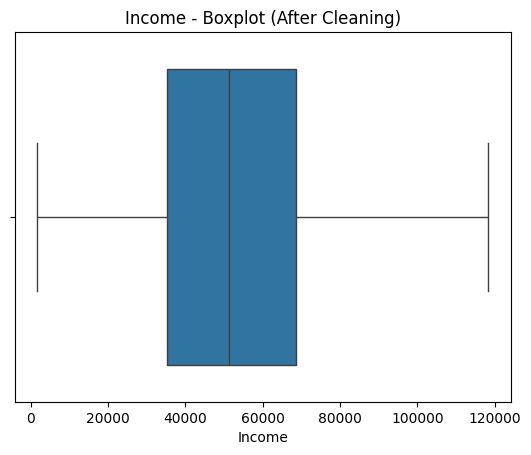

In [51]:
# Income boxplot After capping it
plt.figure()
sns.boxplot(x=df["Income"])
plt.title("Income - Boxplot (After Cleaning)")
plt.show()

In [52]:
# we will use behavioral features for clustering
features = ['Income', 'Age', 'Total_Spent', 'Total_Purchases',
            'Total_Children', 'Tenure', 'Recency',
            'NumWebVisitsMonth']

X = df[features]

In [53]:
# Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Next we will be using the elbow method to find out the optimal number of clusters
Elbow Method: The Elbow Method helps by plotting the Within-Cluster Sum of Squares (WCSS) against increasing k values and looking for a point where the improvement slows down, this point is called the "elbow."

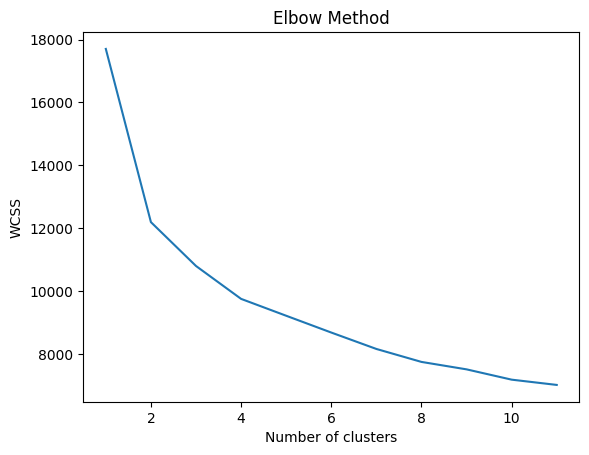

In [54]:
wcss = []

for i in range(1, 12):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 12), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

The Elbow Method indicates an optimal cluster size of 4, where the rate of decrease in WCSS significantly slows. we will try validating this further using silhouette score

The Silhouette Score is a metric used to evaluate the quality of clustering results. It measures how similar each data point is to its own cluster compared to other clusters, helping assess how well the data has been grouped. This score is widely used to evaluate clustering algorithms like K-Means.

In [55]:
# Silhouette Score for k 2 to 11
silhouette_scores = []
k_values = range(2, 12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k}, silhouette score = {score}")

k = 2, silhouette score = 0.27909563950021715
k = 3, silhouette score = 0.2077855857990289
k = 4, silhouette score = 0.1759586078685204
k = 5, silhouette score = 0.16031799855309734
k = 6, silhouette score = 0.15393465621835156
k = 7, silhouette score = 0.1596437357976652
k = 8, silhouette score = 0.16115257193743504
k = 9, silhouette score = 0.15382772219992943
k = 10, silhouette score = 0.15955617651957846
k = 11, silhouette score = 0.15091818098496948


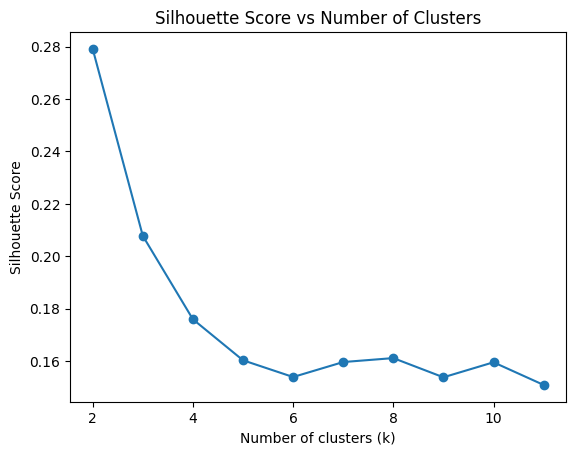

In [56]:
plt.figure()
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

Although k = 2 produced the highest silhouette score, it resulted in overly broad customer groups. A value of k = 4 is selected to achieve more meaningful and actionable customer segmentation while maintaining acceptable clustering quality.

In [57]:
# Model Training
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster distribution
print(df['Cluster'].value_counts())

Cluster
1    590
3    558
2    542
0    523
Name: count, dtype: int64


In [58]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features
)

print(centers)

     Income       Age  Total_Spent  Total_Purchases  Total_Children    Tenure  \
0  1.200658  0.039843     1.213155         0.700296       -1.065830 -0.232856   
1 -1.084473 -0.668658    -0.833674        -0.901529        0.024721  0.315179   
2  0.383165  0.344661     0.491790         0.969775        0.180801  0.669946   
3 -0.350862  0.334882    -0.733266        -0.645109        0.797221 -0.765740   

    Recency  NumWebVisitsMonth  
0  0.012422          -1.235191  
1 -0.078757           0.823623  
2 -0.026600           0.292686  
3  0.097468           0.002566  


In [59]:
centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

print(centers_original)

         Income        Age  Total_Spent  Total_Purchases  Total_Children  \
0  77143.468451  57.548757  1337.768642        20.260038        0.149140   
1  29029.467797  49.261017   104.855932         7.976271        0.966102   
2  59930.951107  61.114391   903.252768        22.326568        1.083026   
3  44475.827061  61.000000   165.336918         9.942652        1.544803   

        Tenure    Recency  NumWebVisitsMonth  
0  4510.600382  49.367113           2.326960  
1  4621.525424  46.728814           7.318644  
2  4693.332103  48.238007           6.031365  
3  4402.741935  51.827957           5.327957  


In [60]:
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

               Income        Age  Total_Spent  Total_Purchases  \
Cluster                                                          
0        77143.468451  57.548757  1337.768642        20.260038   
1        29029.467797  49.261017   104.855932         7.976271   
2        59930.951107  61.114391   903.252768        22.326568   
3        44475.827061  61.000000   165.336918         9.942652   

         Total_Children       Tenure    Recency  NumWebVisitsMonth  
Cluster                                                             
0              0.149140  4510.600382  49.367113           2.326960  
1              0.966102  4621.525424  46.728814           7.318644  
2              1.083026  4693.332103  48.238007           6.031365  
3              1.544803  4402.741935  51.827957           5.327957  


# **Cluster-wise Interpretation**
**Cluster 0 - High Value Premium Customer**
*   Income: Highest (~77k)
*   Total_Spent: Highest (~1337)
*   Purchases: High (~20)
*   Web Visits: Low (~2.3)

Meaning:
*   Wealthy customers who buy directly
*   Not browsing much meaning they know what they want


---



**Cluster 2 - Frequent Buyers (Active Customers)**
*   Income: Medium-high (~59k)
*   Total_Spent: High (~903)
*   Purchases: Highest (~22)
*   Web Visits: Moderate (~6)

Meaning:
*   Regular and active customers
*   Strong engagement as well as consistent buying


---

**Cluster 3 - Moderate Customers (Average Segment)**
*   Income: Mid (~44k)
*   Total_Spent: Low (~165)
*   Purchases: Moderate (~9)
*   Children: Highest (~1.5)

Meaning:
*   Budget-conscious, possibly family-oriented
*   Spend less but still active



---

**Cluster 1 - Low-Value / Window Shoppers**
*   Income: Lowest (~29k)
*   Total_Spent: Very low (~104)
*   Purchases: Lowest (~7)
*   Web Visits: Highest (~7.3)

Meaning:
*   Browse a lot but don't convert
*   Price-sensitive or hesitant buyers








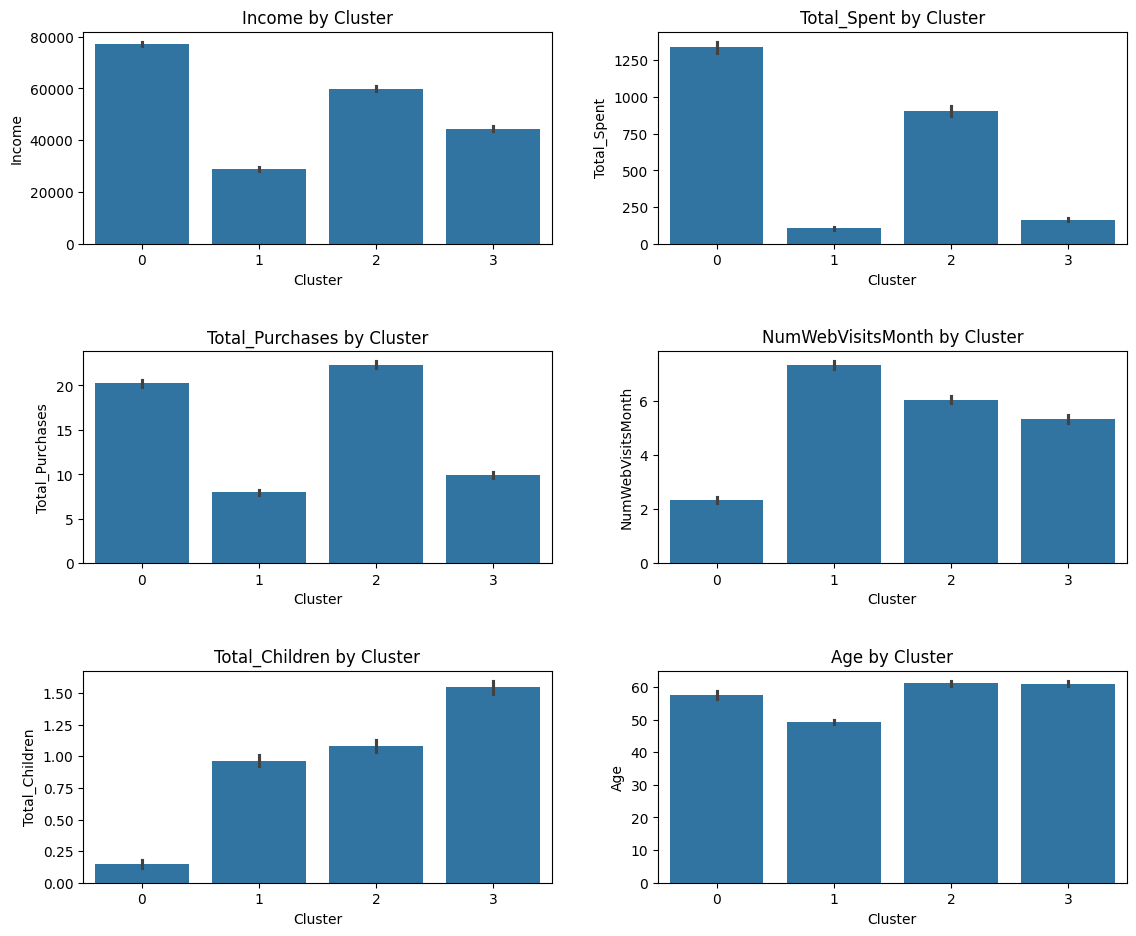

In [61]:
# Visual Comparison of clusters
# Features to visualize
features = ['Income', 'Total_Spent', 'Total_Purchases',
            'NumWebVisitsMonth', 'Total_Children', 'Age']

# Plot each feature
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.barplot(x='Cluster', y=feature, data=df, estimator='mean', ax=axes[i])
    axes[i].set_title(f"{feature} by Cluster")

plt.tight_layout(pad=3.0)
plt.show()

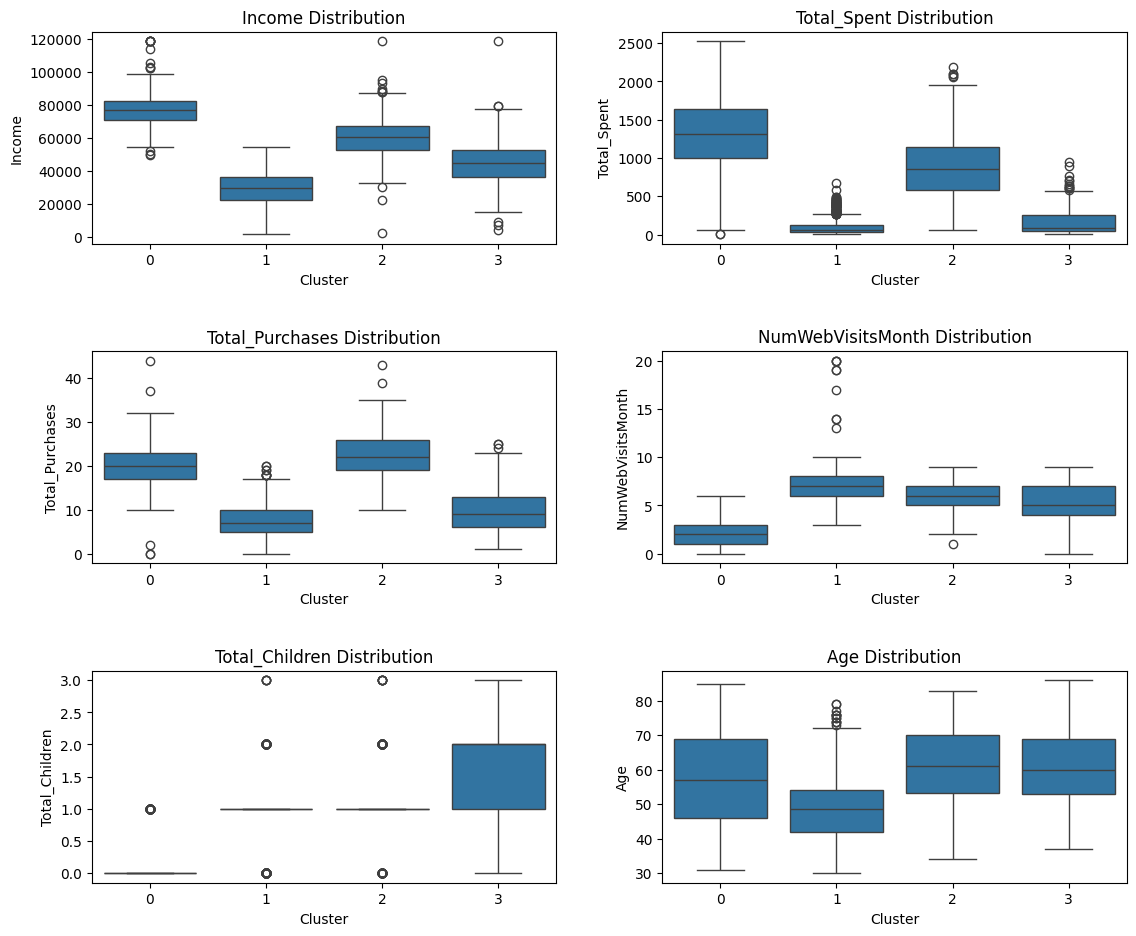

In [62]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Cluster', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f"{feature} Distribution")

plt.tight_layout(pad=3.0)
plt.show()

Visualizations such as bar plots and box plots were are used to compare clusters across key behavioral features, revealing clear differences in income, spending, and purchasing patterns.

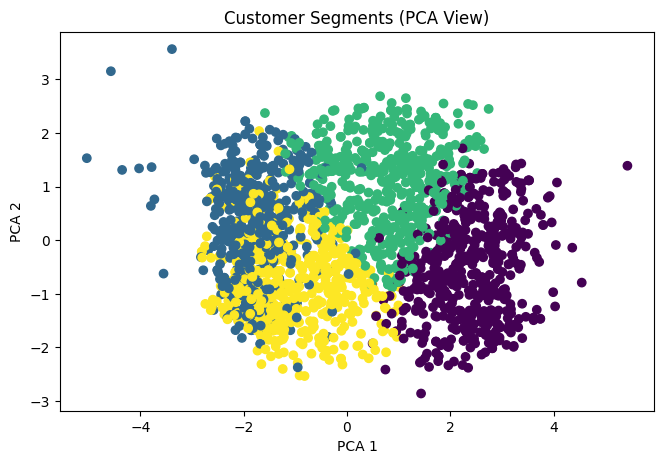

In [63]:
# PCA Visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA View)")

plt.tight_layout(pad=2.0)
plt.show()

The PCA visualization shows that while four clusters are formed, some overlap exists between clusters, indicating moderate separation. One cluster is clearly distinct, while others exhibit partial overlap, aligning with the silhouette score results.

The PCA results are not up to the mark so Lets try Improving K-means by removing 'recency' column

In [65]:
features_new = ['Income', 'Age', 'Total_Spent', 'Total_Purchases',
                'Total_Children', 'Tenure', 'NumWebVisitsMonth']

X_new = df[features_new]

In [66]:
scaler = StandardScaler()
X_scaled_new = scaler.fit_transform(X_new)

In [67]:
kmeans_new = KMeans(n_clusters=4, random_state=42)
df['Cluster_new'] = kmeans_new.fit_predict(X_scaled_new)

In [68]:
score_new = silhouette_score(X_scaled_new, df['Cluster_new'])
print("New Silhouette Score:", score_new)

New Silhouette Score: 0.21289838089975657


In [69]:
print(df.groupby('Cluster_new')[features_new].mean())

                   Income        Age  Total_Spent  Total_Purchases  \
Cluster_new                                                          
0            77070.861217  57.564639  1333.271863        20.249049   
1            28862.173242  48.888508   104.284734         7.982847   
2            59936.416821  61.101664   904.680222        22.343808   
3            44372.976021  61.255773   163.069272         9.872114   

             Total_Children       Tenure  NumWebVisitsMonth  
Cluster_new                                                  
0                  0.153992  4509.340304           2.328897  
1                  0.953688  4617.596913           7.303602  
2                  1.081331  4693.585952           6.027726  
3                  1.554174  4410.404973           5.387211  


### Effect of Removing Recency

Removing the Recency feature led to an improvement in the silhouette score, indicating better cluster separation and reduced noise in the data. However, the overall structure and characteristics of the clusters remained largely unchanged. This suggests that Recency was not a significant factor influencing the clustering process and did not contribute meaningfully to differentiating customer segments. Instead, the clusters were primarily driven by features such as income, spending, and purchasing behavior.


Now lets try with Heirarchial clustering to see if the silhouette score gets any better

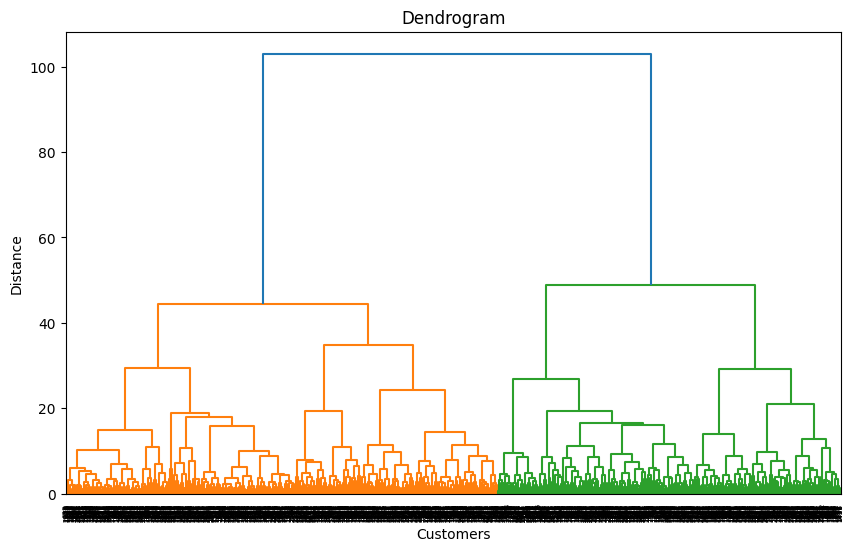

In [71]:
# Heirarchial clustering

plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled_new, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

### Dendrogram Interpretation and Next Step

The dendrogram reveals a clear natural division into two primary clusters, with further sub-clustering possible at lower distance thresholds. This observation is consistent with the silhouette analysis, where the highest silhouette score (0.28) was achieved at k = 2, indicating the strongest cluster separation at this level. In comparison, using k = 4 resulted in a lower silhouette score (0.21), suggesting weaker and more overlapping clusters.

These results indicate that while it is possible to form more clusters, they may not be as distinct or well-separated. Therefore, to align with the inherent structure of the data, hierarchical clustering will now be performed using two macro clusters. This approach focuses on capturing the most natural and well-defined segmentation before exploring finer sub-group distinctions.


In [72]:
hc_2 = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
df['Cluster_HC_2'] = hc_2.fit_predict(X_scaled_new)

In [73]:
score_hc_2 = silhouette_score(X_scaled_new, df['Cluster_HC_2'])
print("Hierarchical (k=2) Silhouette Score:", score_hc_2)

Hierarchical (k=2) Silhouette Score: 0.30486876830009546


In [74]:
df.groupby('Cluster_HC_2')[features_new].mean()

,Income,Age,Total_Spent,Total_Purchases,Total_Children,Tenure,NumWebVisitsMonth
Cluster_HC_2,,,,,,,
0,70383.021472,59.086912,1174.033742,21.599182,0.593047,4582.198364,3.920245
1,37197.499595,55.495547,158.003239,9.576518,1.228340,4538.356275,6.431579


# **Cluster-wise Interpretation**
**Cluster 0 - High Value Customer**
*   Income: High (~70k)
*   Total_Spent: Very high (~1174)
*   Purchases: High (~21.6)
*   Web Visits: Low (~3.9)
*   Children: Fewer (~0.6)

Meaning:
*   Wealthy and highly engaged buyers
*   Spend more and purchase frequently
*   Not browsing much meaning they know what they want


---



**Cluster 1 - Low-Value Customers**
*   Income: Lower (~37k)
*   Total_Spent: Very low (~158)
*   Purchases: Low (~9.6)
*   Web Visits: High (~6.4)
*   Children: More (~1.23)

Meaning:
*   Price-sensitive and less engaged
*   Browse more but convert less
*   Likely budget-conscious (family-oriented)


In [75]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_new)

In [76]:
print(pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

[0.45504414 0.1809157 ]
Total variance explained: 0.6359598413839888


In [77]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster_HC_2']  # or Cluster_new for KMeans

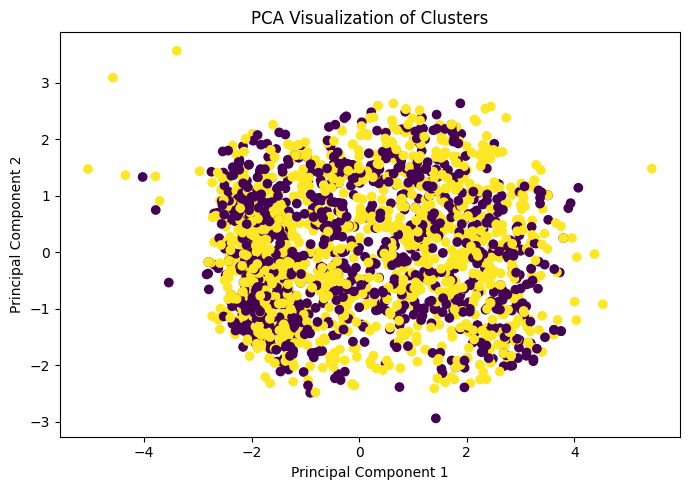

In [78]:
plt.figure(figsize=(7,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Clusters")

plt.tight_layout()
plt.show()

The PCA visualization shows significant overlap between clusters, indicating that the separation is not clearly visible in two dimensions. However, since PCA captures only about 64% of the variance, the clustering structure likely exists in higher-dimensional space. This suggests that customer behavior follows a continuous distribution rather than forming sharply distinct groups.

### Final Conclusion

In this project, customer segmentation was first performed using K-Means clustering. Based on the Elbow Method, k = 4 was selected, which produced meaningful and interpretable groups such as high-value customers, frequent buyers, moderate customers, and low-engagement users. However, the silhouette score for this configuration (~0.21) indicated that the clusters were not strongly separated and had noticeable overlap.

To improve the results, feature refinement was performed by removing the Recency variable, which slightly increased the silhouette score but did not significantly change the cluster structure. This suggested that Recency was not a key driver in segmentation, and the clustering was primarily influenced by income, spending, and purchasing behavior.

Further analysis was carried out using Hierarchical Clustering. The dendrogram and silhouette analysis both indicated that the data naturally forms two primary clusters. When clustering was performed with k = 2, the silhouette score improved significantly (~0.30), showing better separation and more stable clusters. These two clusters broadly represent high-value and low-value customers.

When comparing both approaches, K-Means with k = 4 provides more detailed segmentation, which can be useful for designing targeted strategies. However, the clusters are less distinct and may overlap. On the other hand, Hierarchical clustering with k = 2 produces clearer and more reliable groupings, but the segmentation is too broad for practical business applications.

In real-world scenarios, businesses often prefer slightly less precise but more actionable segmentation. Therefore, while k = 2 is statistically stronger, k = 4 may be more useful for marketing and decision-making, as it captures different types of customer behavior in greater detail.

Further improvements to this analysis could include experimenting with different feature combinations, applying dimensionality reduction techniques with more components, testing other clustering algorithms such as DBSCAN, and performing deeper validation using domain-specific metrics. Additionally, integrating business context or external data could help refine the segmentation and make it more practical for real-world use.
